## スクレイピング

In [2]:
# ---------------------------------------------
# (1) スクレイピング & JSON保存
# ---------------------------------------------
import requests
from bs4 import BeautifulSoup
import time
import json
import os
import re

class Scraper:
    """
    温泉情報をスクレイピングして JSON に保存するクラス
    """
    def __init__(self, base_url="https://onsen.nifty.com/", output_json_path="data.json"):
        self.base_url = base_url.rstrip('/')
        self.output_json_path = output_json_path
    
    def get_prefecture_links(self):
        """トップページから47都道府県のリンク + 都道府県名を取得"""
        print("Fetching prefecture links...")
        r = requests.get(self.base_url)
        soup = BeautifulSoup(r.text, 'html.parser')

        prefecture_links = []
        for a in soup.select('section.map div.prefarea ul li.pref ul li a'):
            href = a.get('href')
            if href and href.startswith('/'):
                full_url = self.base_url + href
                pref_name = a.get_text(strip=True)
                prefecture_links.append((full_url, pref_name))

        print(f"Found {len(prefecture_links)} prefecture links.")
        return prefecture_links

    def get_list_link(self, prefecture_url):
        """都道府県ページから『一覧から探す』のリンクを取得"""
        print(f"Fetching list link from: {prefecture_url}")
        time.sleep(1)
        r = requests.get(prefecture_url)
        soup = BeautifulSoup(r.text, 'html.parser')
        
        list_btn = soup.select_one('a.searchBtn')
        if list_btn:
            href = list_btn.get('href')
            if href and href.startswith('/'):
                full_url = self.base_url + href
                print(f"Found list link: {full_url}")
                return full_url
        print("No list link found.")
        return None

    def get_onsen_links(self, list_url):
        """一覧ページから温泉施設詳細リンクを取得 (ページネーション対応)"""
        print(f"Fetching onsen links from list: {list_url}")
        onsen_links = []
        page_url = list_url
        page_count = 1

        while page_url:
            print(f"Processing page {page_count}...")
            time.sleep(1)
            r = requests.get(page_url)
            soup = BeautifulSoup(r.text, 'html.parser')

            for a in soup.select('div.itemWrap div.contentHeader.clearfix a'):
                href = a.get('href')
                if href and href.startswith('/'):
                    full_url = self.base_url + href
                    onsen_links.append(full_url)

            # 次のページへのリンク
            next_page = soup.select_one('a.next')
            if next_page and next_page.get('href'):
                page_url = self.base_url + next_page['href']
                page_count += 1
            else:
                page_url = None

        print(f"Found {len(onsen_links)} onsen links in total.")
        return onsen_links

    def _parse_rating_and_count(self, rating_elem):
        """
        rating_elem から評価点数を取り出し、親要素付近から「○○件」を取り出して件数を返す。
        戻り値: (rating, rating_count) / (None, None)
        """
        rating_text = rating_elem.get_text(strip=True)
        rating_text = rating_text.replace('点', '').replace('件', '')
        try:
            rating = float(rating_text)
        except ValueError:
            rating = None

        rating_count = None
        parent_text = rating_elem.parent.get_text(strip=True)
        match = re.search(r'(\d+)件', parent_text)
        if match:
            rating_count = int(match.group(1))
        return rating, rating_count

    def _find_rating_and_count(self, soup):
        """
        ページ内から評価点数(rating)と評価件数(rating_count)を探して返す。
        """
        # いくつか候補のセレクタを試す
        selectors = [
            'div.review.clearfix div.point strong',
            'span.score',
            'ul.stars.clearfix strong'
        ]
        for sel in selectors:
            rating_elem = soup.select_one(sel)
            if rating_elem:
                rating, rating_count = self._parse_rating_and_count(rating_elem)
                if rating is not None and rating != 0.0:
                    return rating, rating_count
        return None, None

    def get_onsen_info(self, onsen_url):
        """温泉詳細ページから情報を取得"""
        time.sleep(0.5)
        r = requests.get(onsen_url)
        soup = BeautifulSoup(r.text, 'html.parser')

        # 1) 温泉名
        name_elem = soup.select_one('h1')
        if not name_elem:
            name_elem = soup.select_one('div.title font')
        name = name_elem.get_text(strip=True) if name_elem else None

        # 2) 評価点数 + 評価件数
        rating, rating_count = self._find_rating_and_count(soup)
        if not rating or rating == 0.0:
            print(f"Skipping {name or 'Unknown Onsen'} (評価: {rating})")
            return None

        # 3) 温泉データ抽出 (湯データ / 基本情報)
        onsen_data = {}
        # A) 湯データ
        yu_data_section = soup.select_one('div#data.section3')
        if yu_data_section:
            for dl in yu_data_section.select('dl.dateList3'):
                dt_elements = dl.select('dt')
                dd_elements = dl.select('dd')
                for dt, dd in zip(dt_elements, dd_elements):
                    key = dt.get_text(strip=True)
                    value = dd.get_text(strip=True)
                    onsen_data[key] = value
        # B) 基本情報
        if not onsen_data:
            fields_to_extract = ["源泉名", "特徴", "泉質分類", "効能分類"]
            for li_tag in soup.select('section#secBasicInfo li.clearfix'):
                head = li_tag.select_one('.headRow')
                content = li_tag.select_one('.content')
                if head and content:
                    key = head.get_text(strip=True)
                    if key in fields_to_extract:
                        onsen_data[key] = content.get_text(strip=True)
            for p in soup.select('section#secBasicInfo p.headRow'):
                key = p.get_text(strip=True)
                if key in fields_to_extract and key not in onsen_data:
                    next_elem = p.find_next_sibling()
                    if next_elem and next_elem.name == 'ul':
                        items = [li.get_text(strip=True) for li in next_elem.select('li')]
                        onsen_data[key] = ", ".join(items)

        info = {
            'url': onsen_url,
            'name': name,
            'rating': rating,
            'rating_count': rating_count,
            'onsen_data': onsen_data
        }
        return info
    
    def save_to_json(self, data):
        """JSONファイルにデータを追記保存"""
        if not os.path.exists(self.output_json_path):
            with open(self.output_json_path, "w", encoding="utf-8") as f:
                json.dump([data], f, ensure_ascii=False, indent=4)
        else:
            with open(self.output_json_path, "r+", encoding="utf-8") as f:
                existing_data = json.load(f)
                existing_data.append(data)
                f.seek(0)
                json.dump(existing_data, f, ensure_ascii=False, indent=4)

    def run_scraping(self):
        """
        全都道府県についてスクレイピング -> JSONに保存
        """
        prefectures = self.get_prefecture_links()
        total_onsen_count = 0

        for pref_url, pref_name in prefectures:
            list_url = self.get_list_link(pref_url)
            if not list_url:
                continue

            onsen_links = self.get_onsen_links(list_url)
            total_onsen_count += len(onsen_links)

            for onsen_url in onsen_links:
                info = self.get_onsen_info(onsen_url)
                if info:
                    info["prefecture"] = pref_name
                    print(f"Fetched: {info['name']} "
                          f"| {pref_name} "
                          f"| 評価: {info['rating']} "
                          f"| 件数: {info['rating_count']}")
                    self.save_to_json(info)

        print(f"Total onsen links fetched: {total_onsen_count}")
        print(f"Results saved to {self.output_json_path}")


# ===== 実行部 =====
# 実際にスクレイピングを行い data.json を出力する
if __name__ == "__main__":
    # 必要に応じて出力ファイル名を変えても良い
    scraper = Scraper(output_json_path="data.json")
    scraper.run_scraping()

Fetching prefecture links...
Found 47 prefecture links.
Fetching list link from: https://onsen.nifty.com/hokkaido/
Found list link: https://onsen.nifty.com/hokkaido/search/
Fetching onsen links from list: https://onsen.nifty.com/hokkaido/search/
Processing page 1...
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...
Processing page 10...
Processing page 11...
Processing page 12...
Processing page 13...
Processing page 14...
Processing page 15...
Processing page 16...
Processing page 17...
Processing page 18...
Processing page 19...
Processing page 20...
Processing page 21...
Processing page 22...
Processing page 23...
Processing page 24...
Processing page 25...
Processing page 26...
Processing page 27...
Processing page 28...
Processing page 29...
Processing page 30...
Processing page 31...
Processing page 32...
Processing page 33...
Processing page 34...
Processing page

In [2]:
# ---------------------------------------------
# (2) データベース格納
# ---------------------------------------------
import sqlite3
import json
import os

class DBHandler:
    """
    温泉データを SQLite データベースに格納・参照するクラス
    """
    def __init__(self, db_path="onsen_data.db"):
        self.db_path = db_path
        self._initialize_db()

    def _initialize_db(self):
        """テーブルがなければ作成する"""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()

        cursor.execute("""
        CREATE TABLE IF NOT EXISTS main_table (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            url TEXT,
            name TEXT,
            rating REAL,
            rating_count INTEGER,
            prefecture TEXT
        )
        """)
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS onsen_data_table (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            main_id INTEGER,
            key_name TEXT,
            key_value TEXT,
            FOREIGN KEY (main_id) REFERENCES main_table(id)
        )
        """)

        conn.commit()
        conn.close()

    def insert_data_from_json(self, json_path):
        """JSONファイルの内容をDBにINSERT"""
        if not os.path.exists(json_path):
            print(f"JSON file not found: {json_path}")
            return

        with open(json_path, "r", encoding="utf-8") as f:
            data_list = json.load(f)

        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()

        for item in data_list:
            # main_tableへ
            cursor.execute("""
                INSERT INTO main_table (url, name, rating, rating_count, prefecture)
                VALUES (?, ?, ?, ?, ?)
            """, (
                item.get("url"),
                item.get("name"),
                item.get("rating"),
                item.get("rating_count"),
                item.get("prefecture")
            ))
            main_id = cursor.lastrowid

            # onsen_data_tableへ
            onsen_data = item.get("onsen_data", {})
            if isinstance(onsen_data, dict):
                for key, value in onsen_data.items():
                    cursor.execute("""
                        INSERT INTO onsen_data_table (main_id, key_name, key_value)
                        VALUES (?, ?, ?)
                    """, (main_id, key, value))

        conn.commit()
        conn.close()
        print(f"Data inserted into {self.db_path}")

    def fetch_all_data(self):
        """
        main_table と onsen_data_table を突き合わせて
        リスト[ {url, name, rating, rating_count, prefecture, onsen_data: {key:val, ...}}, ... ]
        の形式で返す
        """
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()

        # main_table全部
        cursor.execute("SELECT id, url, name, rating, rating_count, prefecture FROM main_table")
        rows = cursor.fetchall()

        data_list = []
        for row in rows:
            main_id, url, name, rating, rating_count, prefecture = row

            # onsen_data_table から key_name, key_value を取得
            cursor.execute("""
                SELECT key_name, key_value
                FROM onsen_data_table
                WHERE main_id=?
            """, (main_id,))
            data_rows = cursor.fetchall()

            onsen_data = {}
            for (k, v) in data_rows:
                onsen_data[k] = v

            data_list.append({
                "url": url,
                "name": name,
                "rating": rating,
                "rating_count": rating_count,
                "prefecture": prefecture,
                "onsen_data": onsen_data
            })

        conn.close()
        return data_list


# ===== 実行部 =====
# JSON (data.json) からデータベースに格納
if __name__ == "__main__":
    db_handler = DBHandler(db_path="onsen_data.db")
    db_handler.insert_data_from_json("data.json")  # スクレイピングで作成した data.json を読み込む

    # 動作確認: DB から全件取得して件数を表示
    all_data = db_handler.fetch_all_data()
    print(f"DBに格納されているデータ数: {len(all_data)}")
    if len(all_data) > 0:
        print("例:")
        print(all_data[0])  # 先頭1件の例を表示

Data inserted into onsen_data.db
DBに格納されているデータ数: 24493
例:
{'url': 'https://onsen.nifty.com/asahikawa-onsen/onsen005764/', 'name': None, 'rating': 4.3, 'rating_count': 36, 'prefecture': '北海道', 'onsen_data': {}}


## クラスタリング（Janome を使う場合）

=== Elbow Method ===


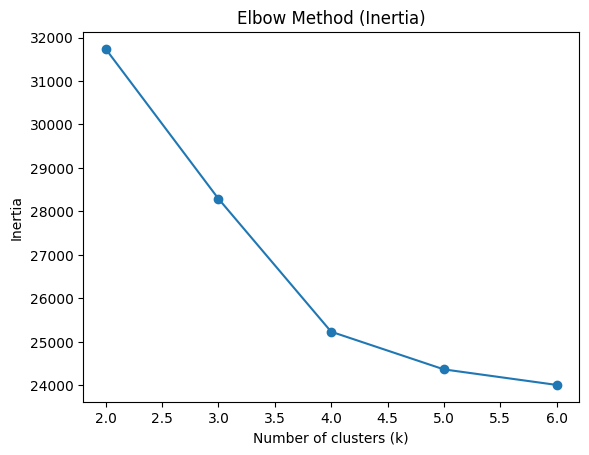

=== Silhouette Method ===


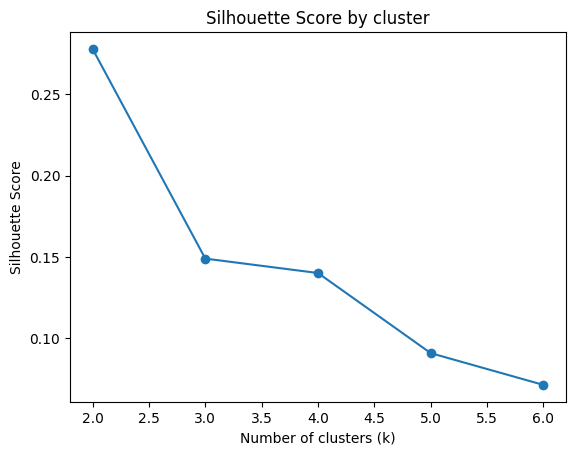

=== Clustering with k=4 ===
---- Cluster membership ----
Cluster 0:
  https://onsen.nifty.com/tokachi-onsen/onsen017266/ (rating=5.0, pref=北海道)
  https://onsen.nifty.com/asahikawa-onsen/onsen010882/ (rating=5.0, pref=北海道)
  https://onsen.nifty.com/obihiro-onsen/onsen004979/ (rating=4.4, pref=北海道)
  https://onsen.nifty.com/noboribetsu-onsen/onsen000097/ (rating=4.6, pref=北海道)
  https://onsen.nifty.com/monbetsu-onsen/onsen006208/ (rating=4.5, pref=北海道)
  https://onsen.nifty.com/abashiri-onsen/onsen006267/ (rating=4.6, pref=北海道)
  https://onsen.nifty.com/yuubari-onsen/onsen004931/ (rating=4.4, pref=北海道)
  https://onsen.nifty.com/furano-onsen/onsen000161/ (rating=4.5, pref=北海道)
  https://onsen.nifty.com/kitami-onsen/onsen005584/ (rating=4.4, pref=北海道)
  https://onsen.nifty.com/noboribetsu-onsen/onsen000137/ (rating=4.7, pref=北海道)
  https://onsen.nifty.com/chitose-onsen/onsen006851/ (rating=4.8, pref=北海道)
  https://onsen.nifty.com/tokachi-onsen/onsen006328/ (rating=4.4, pref=北海道)
  https://

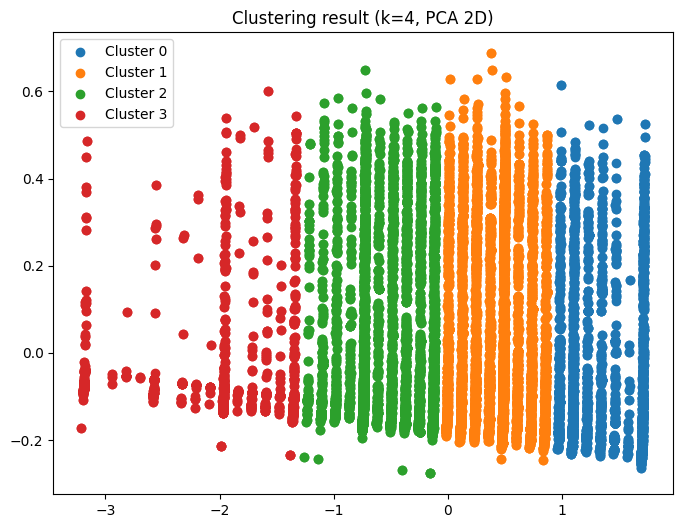

=== Cluster 0 統計 ===
施設数: 3734
評価平均: 4.716
都道府県内訳(上位5件):
  長野: 280 件
  大分: 236 件
  静岡: 202 件
  熊本: 196 件
  北海道: 178 件

=== Cluster 1 統計 ===
施設数: 10358
評価平均: 3.960
都道府県内訳(上位5件):
  北海道: 684 件
  長野: 672 件
  静岡: 578 件
  群馬: 530 件
  大分: 500 件

=== Cluster 2 統計 ===
施設数: 7779
評価平均: 3.154
都道府県内訳(上位5件):
  東京: 512 件
  北海道: 496 件
  大阪: 492 件
  長野: 440 件
  静岡: 364 件

=== Cluster 3 統計 ===
施設数: 2622
評価平均: 1.936
都道府県内訳(上位5件):
  大阪: 948 件
  京都: 308 件
  兵庫: 186 件
  東京: 92 件
  奈良: 76 件



In [11]:
# ---------------------------------------------
# (3) クラスタリング分析 (DBからデータ取得)
# ---------------------------------------------
import re
import numpy as np
from janome.tokenizer import Tokenizer

# ベクトル化・クラスタリング・可視化
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

class ClusteringAnalysis:
    """
    DBからデータを取得してクラスタリングを行うクラス
    """
    def __init__(self, db_handler):
        """
        db_handler: DBHandler のインスタンス
        """
        self.db_handler = db_handler
        self.tokenizer = Tokenizer()

        # 取得したデータ保持用
        self.data_list = []
        self.texts = []
        self.ratings = []
        self.urls = []
        self.prefectures = []

    def _normalize_text(self, text: str) -> str:
        """テキストの簡易正規化: \nなどをスペースに置き換え、余分な空白を削除"""
        if not text:
            return ""
        text = text.replace("\n", " ")
        text = text.replace("\u3000", " ")
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    def _tokenize_janome(self, text: str) -> str:
        """
        Janomeで形態素解析を行い、
        名詞・形容詞・動詞のみをスペース区切りで連結
        """
        words = []
        for token in self.tokenizer.tokenize(text):
            pos = token.part_of_speech.split(',')[0]
            if pos in ["名詞", "形容詞", "動詞"]:
                words.append(token.surface)
        return " ".join(words)

    def fetch_and_prepare_data(self):
        """
        DBからデータを取得し、クラスタリング用に
         - texts: TF-IDF化するテキスト
         - ratings: 数値（評価）
         - urls / prefectures などを準備
        """
        self.data_list = self.db_handler.fetch_all_data()

        for item in self.data_list:
            onsen_data = item.get("onsen_data", {})
            text_parts = []
            for key in ["泉質", "特徴", "効能", "泉質分類", "効能分類"]:
                val = onsen_data.get(key, "")
                text_parts.append(val)

            # 施設名も
            name_str = item.get("name") or ""
            text_parts.append(name_str)

            # 正規化 & 形態素解析
            merged_text = " ".join(text_parts)
            merged_text = self._normalize_text(merged_text)
            tokenized = self._tokenize_janome(merged_text)
            self.texts.append(tokenized)

            # 数値（評価）
            rating_val = item.get("rating", 0.0)
            self.ratings.append(rating_val)

            # その他
            self.urls.append(item.get("url", ""))
            self.prefectures.append(item.get("prefecture", "不明"))

    def run_clustering_analysis(self, k=4):
        """
        k: クラスタ数を指定
        1) TF-IDFベクトル化
        2) 評価(rating) を標準化して結合
        3) K-meansクラスタリング
        4) 結果の可視化
           - 各クラスタ内のURLと評価
           - 各クラスタの評価平均
           - 各クラスタ内で多い都道府県トップ5
        """
        if not self.texts:
            raise ValueError("No data to analyze. Call fetch_and_prepare_data() first.")

        # 1) TF-IDFベクトル化
        stopwords = [
    "温泉", "湯", "泉", "アルカリ性",
    "冷え性", "痛", "病", "関節", "筋肉",
    "閉館", "ホテル", "特徴"
    ]
        vectorizer = TfidfVectorizer(
            token_pattern='(?u)\\b\\w+\\b',
            max_df=0.9,
            min_df=1,
            stop_words=stopwords
        )
        X_text = vectorizer.fit_transform(self.texts)  # shape: (N, vocab_size)

        # 2) rating を標準化して結合
        rating_array = np.array(self.ratings).reshape(-1, 1)
        scaler = StandardScaler()
        rating_scaled = scaler.fit_transform(rating_array)  # (N, 1)
        rating_sparse = csr_matrix(rating_scaled)
        X = hstack([X_text, rating_sparse])  # (N, vocab_size + 1)

        # 3) K-meansクラスタリング
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X)

        # 各クラスタに属するレコードのindexを集計
        cluster_dict = defaultdict(list)
        for i, label in enumerate(labels):
            cluster_dict[label].append(i)

        # クラスタごとの内訳を出力
        print("---- Cluster membership ----")
        for cluster_id in range(k):
            print(f"Cluster {cluster_id}:")
            for idx in cluster_dict[cluster_id]:
                print(f"  {self.urls[idx]} (rating={self.ratings[idx]}, pref={self.prefectures[idx]})")
            print()

        # クラスタ中心から上位単語 (テキスト部分のみ)
        # cluster_centers_.shape = (k, vocab_size+1) → 最後の1次元が rating用
        order_centroids = model.cluster_centers_[:, :-1].argsort()[:, ::-1]
        terms = vectorizer.get_feature_names_out()
        for cluster_id in range(k):
            print(f"Cluster {cluster_id} top words:")
            top_words = [terms[ind] for ind in order_centroids[cluster_id, :10]]
            print(" ".join(top_words))
            print()

        # 4) PCAによる2次元散布図
        X_dense = X.toarray()
        pca = PCA(n_components=2, random_state=42)
        X_2d = pca.fit_transform(X_dense)

        explained = pca.explained_variance_ratio_
        print(f"PCA explained_variance_ratio_: {explained}")
        print(f"-> PC1: {explained[0]*100:.2f}%, PC2: {explained[1]*100:.2f}%")

        plt.figure(figsize=(8, 6))
        for cluster_id in range(k):
            mask = (labels == cluster_id)
            plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"Cluster {cluster_id}")
        plt.title(f"Clustering result (k={k}, PCA 2D)")
        plt.legend()
        plt.show()

        # 追加要素: 各クラスタの評価平均 & 多い都道府県TOP5
        for cluster_id in range(k):
            indices = cluster_dict[cluster_id]
            cluster_prefs = [self.prefectures[i] for i in indices]
            cluster_ratings = [self.ratings[i] for i in indices]

            pref_count = Counter(cluster_prefs)
            avg_rating = np.mean(cluster_ratings) if len(cluster_ratings) > 0 else 0.0

            print(f"=== Cluster {cluster_id} 統計 ===")
            print(f"施設数: {len(indices)}")
            print(f"評価平均: {avg_rating:.3f}")

            print("都道府県内訳(上位5件):")
            for p, cnt in pref_count.most_common(5):
                print(f"  {p}: {cnt} 件")
            print()

    def run_elbow_method(self, max_k=8):
        """
        エルボー法 (inertia) をグラフ化して最適クラスタ数の目安を検討
        """
        if not self.texts:
            raise ValueError("No data to analyze. Call fetch_and_prepare_data() first.")

        vectorizer = TfidfVectorizer(
            token_pattern='(?u)\\b\\w+\\b',
            max_df=0.9,
            min_df=1
        )
        X_text = vectorizer.fit_transform(self.texts)

        rating_array = np.array(self.ratings).reshape(-1, 1)
        scaler = StandardScaler()
        rating_scaled = scaler.fit_transform(rating_array)
        rating_sparse = csr_matrix(rating_scaled)
        X = hstack([X_text, rating_sparse])

        inertias = []
        Ks = range(2, max_k + 1)
        for k in Ks:
            model = KMeans(n_clusters=k, random_state=42)
            model.fit(X)
            inertias.append(model.inertia_)

        plt.figure()
        plt.plot(Ks, inertias, marker='o')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Inertia")
        plt.title("Elbow Method (Inertia)")
        plt.show()

    def run_silhouette_method(self, max_k=8):
        """
        シルエットスコアをグラフ化して最適クラスタ数の目安を検討
        """
        if not self.texts:
            raise ValueError("No data to analyze. Call fetch_and_prepare_data() first.")

        vectorizer = TfidfVectorizer(
            token_pattern='(?u)\\b\\w+\\b',
            max_df=0.9,
            min_df=1
        )
        X_text = vectorizer.fit_transform(self.texts)

        rating_array = np.array(self.ratings).reshape(-1, 1)
        scaler = StandardScaler()
        rating_scaled = scaler.fit_transform(rating_array)
        rating_sparse = csr_matrix(rating_scaled)
        X = hstack([X_text, rating_sparse])

        scores = []
        Ks = range(2, max_k + 1)
        for k in Ks:
            model = KMeans(n_clusters=k, random_state=42)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            scores.append(score)

        plt.figure()
        plt.plot(Ks, scores, marker='o')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Silhouette Score")
        plt.title("Silhouette Score by cluster")
        plt.show()


# ===== 実行部 =====
if __name__ == "__main__":
    # 1) まずはDBHandlerを用意 (同じdb_pathで)
    db_handler = DBHandler(db_path="onsen_data.db")

    # 2) ClusteringAnalysisインスタンス生成 & データ取得
    cluster_analyzer = ClusteringAnalysis(db_handler=db_handler)
    cluster_analyzer.fetch_and_prepare_data()

    # 3) エルボー法・シルエットスコアでクラスタ数の目安を確認 (任意で実行)
    print("=== Elbow Method ===")
    cluster_analyzer.run_elbow_method(max_k=6)

    print("=== Silhouette Method ===")
    cluster_analyzer.run_silhouette_method(max_k=6)

    # 4) 例として k=4 でクラスタリング分析を実行
    print("=== Clustering with k=4 ===")
    cluster_analyzer.run_clustering_analysis(k=4)